# End-to-End Usage Example
This notebook demonstrates a full workflow for `intervene_ar`: install/import, data preparation, train/load (Phase 1 + Phase 2), and evaluation.

In [23]:
!nvidia-smi --query-gpu=name,memory.total,memory.free,compute_cap --format=csv,noheader

'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


In [24]:
%pip install -e .

Obtaining file:///C:/Users/shaha/Work/Personal/Transform-EMR
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for intervene_ar (pyproject.toml): started
  Building editable for intervene_ar (pyproject.toml): finished with status 'done'
  Created wheel for intervene_ar: filename=intervene_ar-0.1-0.editable-py3-none-any.whl size=3982 sha256=de1b8adff0375227bb136fddb5d043a44a7481b97a901d855899e455a54ea4d3
  Stored in directory: C:\Users\shaha\AppData\Local\Temp\pip-ephem-wheel-cache-0zr714ui\wheels\6d\6c\f9\48dfb1d8b6464f43416b05f


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import importlib
import sys
from pathlib import Path

import joblib
import pandas as pd
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import intervene_ar.config.dataset_config as dataset_config
import intervene_ar.config.model_config as model_config
from intervene_ar import dataset, schedulers, utils, loss, embedder, transformer, inference, diagnose

# Snapshot dynamic keys (computed at runtime, not defined in config files).
_old_model_config = dict(getattr(model_config, "MODEL_CONFIG", {}))
_old_training_settings = dict(getattr(model_config, "TRAINING_SETTINGS", {}))
_old_filter_criteria = getattr(dataset_config, "INCLUSION_EXCLUSION_CRITERIA", None)

for module in (
    dataset_config,
    model_config,
    dataset,
    schedulers,
    utils,
    loss,
    embedder,
    transformer,
    inference,
    diagnose
):
    importlib.reload(module)

# Restore only keys absent from the reloaded file (e.g. ctx_dim set by data cell).
# File-defined keys are intentionally left as reloaded.
for k, v in _old_model_config.items():
    if k not in model_config.MODEL_CONFIG:
        model_config.MODEL_CONFIG[k] = v
for k, v in _old_training_settings.items():
    if k not in model_config.TRAINING_SETTINGS:
        model_config.TRAINING_SETTINGS[k] = v
if _old_filter_criteria is not None and not hasattr(dataset_config, "INCLUSION_EXCLUSION_CRITERIA"):
    dataset_config.INCLUSION_EXCLUSION_CRITERIA = _old_filter_criteria

from intervene_ar.config.model_config import MODEL_CONFIG, TRAINING_SETTINGS

print("Modules reloaded. File-defined config updated; runtime-computed keys preserved.")
print(f"ctx_dim = {MODEL_CONFIG.get('ctx_dim')}  |  embed_dim = {MODEL_CONFIG.get('embed_dim')}")

Modules reloaded. File-defined config updated; runtime-computed keys preserved.
ctx_dim = 2  |  embed_dim = 256


In [26]:
# Optional cleanup controls for checkpoint artifacts (useful on restricted VMs)
CLEAN_SCALER = False
CLEAN_TOKENIZER = False
CLEAN_EMBEDDER = False
CLEAN_TRANSFORMER = False

# Convenience switch: if True, cleans all artifacts above
CLEAN_ALL = True

clean_scaler = CLEAN_SCALER or CLEAN_ALL
clean_tokenizer = CLEAN_TOKENIZER or CLEAN_ALL
clean_embedder = CLEAN_EMBEDDER or CLEAN_ALL
clean_transformer = CLEAN_TRANSFORMER or CLEAN_ALL

paths_to_delete = []

if clean_scaler:
    paths_to_delete.append(Path(model_config.CHECKPOINT_PATH) / "scaler.pkl")
if clean_tokenizer:
    paths_to_delete.append(Path(model_config.CHECKPOINT_PATH) / "tokenizer.pt")
if clean_embedder:
    embedder_ckpt = Path(model_config.PHASE1_CHECKPOINT).resolve()
    paths_to_delete.extend([embedder_ckpt, embedder_ckpt.parent / "ckpt_last.pt"])
if clean_transformer:
    transformer_ckpt = Path(model_config.PHASE2_CHECKPOINT).resolve()
    paths_to_delete.extend([transformer_ckpt, transformer_ckpt.parent / "ckpt_last.pt"])
    transformer_ckpt = Path(model_config.PHASE3_CHECKPOINT).resolve()
    paths_to_delete.extend([transformer_ckpt, transformer_ckpt.parent / "ckpt_last.pt"])

if not paths_to_delete:
    print("No cleanup selected. Set CLEAN_* = True (or CLEAN_ALL = True) and re-run this cell.")
else:
    removed, missing, failed = [], [], []
    for path in dict.fromkeys(paths_to_delete):  # dedupe while preserving order
        try:
            if path.exists():
                path.unlink()
                removed.append(path)
            else:
                missing.append(path)
        except Exception as exc:
            failed.append((path, str(exc)))

    print("Checkpoint cleanup summary:")
    print(f"  Removed: {len(removed)}")
    for path in removed:
        print(f"    - {path}")

    print(f"  Not found: {len(missing)}")
    for path in missing:
        print(f"    - {path}")

    if failed:
        print(f"  Failed: {len(failed)}")
        for path, err in failed:
            print(f"    - {path} -> {err}")

Checkpoint cleanup summary:
  Removed: 2
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\scaler.pkl
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\tokenizer.pt
  Not found: 6
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase1\ckpt_best.pt
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase1\ckpt_last.pt
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase2\ckpt_best.pt
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase2\ckpt_last.pt
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase3\ckpt_best.pt
    - C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase3\ckpt_last.pt


## 1) Data Load and Processing

In [27]:
# Data Source
# DATA_SOURCE_MODE:
#   "pre_split" use TRAIN_* / TEST_* files from dataset_config (recommended for VM runs)
#   "source_split" load from data/source/, split by PatientId, optionally save splits
DATA_SOURCE_MODE = "pre_split"

if DATA_SOURCE_MODE not in {"pre_split", "source_split"}:
    raise ValueError("DATA_SOURCE_MODE must be 'pre_split' or 'source_split'.")

SOURCE_TEMPORAL_DATA_FILE = PROJECT_ROOT / "data" / "source" / "synthetic_diabetes_temporal_data.csv"
SOURCE_CTX_DATA_FILE      = PROJECT_ROOT / "data" / "source" / "synthetic_diabetes_context_data.csv"
SOURCE_TEST_SIZE   = 0.2
SOURCE_SPLIT_SEED  = 42
CONTEXT_COLUMN_RENAME_MAP = {}
CONTEXT_COLUMNS_TO_DROP   = []
SAVE_SOURCE_SPLITS = True
SOURCE_OUTPUT_TRAIN_TEMPORAL_FILE = PROJECT_ROOT / "data" / "train" / "synthetic_diabetes_temporal_data.csv"
SOURCE_OUTPUT_TRAIN_CTX_FILE      = PROJECT_ROOT / "data" / "train" / "synthetic_diabetes_context_data.csv"
SOURCE_OUTPUT_TEST_TEMPORAL_FILE  = PROJECT_ROOT / "data" / "test"  / "synthetic_diabetes_temporal_data.csv"
SOURCE_OUTPUT_TEST_CTX_FILE       = PROJECT_ROOT / "data" / "test"  / "synthetic_diabetes_context_data.csv"

# Train/Val split settings
TRAIN_VAL_SIZE       = 0.2
TRAIN_VAL_SPLIT_SEED = 42

# Optional patient sampling (None = all)
SAMPLE_PATIENTS = None
NUM_WORKERS = 4 if SAMPLE_PATIENTS is None else 0

# Tokenizer
TOKENIZER_PATH     = Path(model_config.CHECKPOINT_PATH) / "tokenizer.pt"
TOKENIZER_FIT_SCOPE = "all_processed"   # "train_only" | "train_val" | "all_processed"

# Misc
AUTO_SET_CTX_DIM = True
K_RANGE          = range(3, 8)
MAX_LEN          = 1000
TEMPERATURE      = 1.0
TIME_BIAS_HOURS  = 48

print(f"Data mode: {DATA_SOURCE_MODE}")

# Load raw data
if DATA_SOURCE_MODE == "pre_split":
    train_temporal_raw = pd.read_csv(dataset_config.TRAIN_TEMPORAL_DATA_FILE, low_memory=False)
    train_ctx_raw      = pd.read_csv(dataset_config.TRAIN_CTX_DATA_FILE)
    eval_temporal_raw  = pd.read_csv(dataset_config.TEST_TEMPORAL_DATA_FILE,  low_memory=False)
    eval_ctx_raw       = pd.read_csv(dataset_config.TEST_CTX_DATA_FILE)
else:
    source_temporal_raw = pd.read_csv(SOURCE_TEMPORAL_DATA_FILE, low_memory=False)
    source_ctx_raw      = pd.read_csv(SOURCE_CTX_DATA_FILE)
    if CONTEXT_COLUMN_RENAME_MAP:
        source_ctx_raw = source_ctx_raw.rename(columns=CONTEXT_COLUMN_RENAME_MAP)
    if CONTEXT_COLUMNS_TO_DROP:
        source_ctx_raw = source_ctx_raw.drop(columns=CONTEXT_COLUMNS_TO_DROP, errors="ignore")
    source_pids = np.sort(source_temporal_raw["PatientId"].dropna().unique())
    train_pool_ids, eval_ids = train_test_split(
        source_pids, test_size=SOURCE_TEST_SIZE, random_state=SOURCE_SPLIT_SEED)
    train_temporal_raw = source_temporal_raw[source_temporal_raw["PatientId"].isin(train_pool_ids)].copy()
    train_ctx_raw      = source_ctx_raw[source_ctx_raw["PatientId"].isin(train_pool_ids)].copy()
    eval_temporal_raw  = source_temporal_raw[source_temporal_raw["PatientId"].isin(eval_ids)].copy()
    eval_ctx_raw       = source_ctx_raw[source_ctx_raw["PatientId"].isin(eval_ids)].copy()
    if SAVE_SOURCE_SPLITS:
        for p in [SOURCE_OUTPUT_TRAIN_TEMPORAL_FILE, SOURCE_OUTPUT_TRAIN_CTX_FILE,
                  SOURCE_OUTPUT_TEST_TEMPORAL_FILE, SOURCE_OUTPUT_TEST_CTX_FILE]:
            p.parent.mkdir(parents=True, exist_ok=True)
        train_temporal_raw.to_csv(SOURCE_OUTPUT_TRAIN_TEMPORAL_FILE, index=False)
        train_ctx_raw.to_csv(SOURCE_OUTPUT_TRAIN_CTX_FILE, index=False)
        eval_temporal_raw.to_csv(SOURCE_OUTPUT_TEST_TEMPORAL_FILE, index=False)
        eval_ctx_raw.to_csv(SOURCE_OUTPUT_TEST_CTX_FILE, index=False)

if SAMPLE_PATIENTS is not None:
    sampled_ids = sorted(random.sample(list(train_temporal_raw["PatientId"].dropna().unique()), SAMPLE_PATIENTS))
    train_temporal_raw = train_temporal_raw[train_temporal_raw["PatientId"].isin(sampled_ids)].copy()
    train_ctx_raw      = train_ctx_raw[train_ctx_raw["PatientId"].isin(sampled_ids)].copy()

# Process full train pool (fits scaler; enables stratified split on processed tokens)
print("Processing full train pool (fits scaler)...")
train_pool_processor = dataset.DataProcessor(
    train_temporal_raw.copy(), train_ctx_raw.copy(),
    scaler=None,
    tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
)
train_pool_df, train_pool_ctx_df = train_pool_processor.run()

scaler_path = Path(model_config.CHECKPOINT_PATH) / "scaler.pkl"
if not scaler_path.exists():
    raise FileNotFoundError(f"Expected scaler at {scaler_path}")
scaler = joblib.load(scaler_path)

# Build / load tokenizer
if TOKENIZER_PATH.exists():
    print(f"Loading tokenizer from: {TOKENIZER_PATH}")
    tokenizer = dataset.EMRTokenizer.load(TOKENIZER_PATH)
else:
    print("Processing eval split for tokenizer fitting...")
    eval_proc_df = dataset.DataProcessor(
        eval_temporal_raw.copy(), eval_ctx_raw.copy(),
        scaler=scaler,
        tak_repo_path=dataset_config.TAK_REPO_PATH,
        checkpoint_path=model_config.CHECKPOINT_PATH,
    ).run()[0]

    if TOKENIZER_FIT_SCOPE == "train_only":
        tokenizer_fit_df = train_pool_df
    elif TOKENIZER_FIT_SCOPE == "train_val":
        tokenizer_fit_df = train_pool_df   # val not yet processed; use full pool as approximation
    else:
        tokenizer_fit_df = pd.concat([train_pool_df, eval_proc_df], ignore_index=True)

    print(f"Building tokenizer ({TOKENIZER_FIT_SCOPE}): "
          f"{tokenizer_fit_df['PatientId'].nunique()} patients, "
          f"{tokenizer_fit_df['PositionToken'].nunique()} unique tokens")
    tokenizer = dataset.EMRTokenizer.from_processed_df(tokenizer_fit_df)
    tokenizer.save(TOKENIZER_PATH)
    print(f"Saved tokenizer to: {TOKENIZER_PATH}")

# Stratified train/val split
# Strata key = each patient's rarest valid outcome (by prevalence ratio).
# Guarantees at least one representative of each kept outcome in both train and val.
train_pool_pids = np.sort(train_pool_df["PatientId"].dropna().unique())
patient_tokens_map = train_pool_df.groupby("PatientId")["PositionToken"].apply(set)
strat_labels = []
for pid in train_pool_pids:
    patient_outcomes = [n for n in dataset_config.OUTCOMES if n in patient_tokens_map.get(pid, set())]
    if patient_outcomes and tokenizer.outcome_patient_ratios:
        rarest = min(patient_outcomes, key=lambda n: tokenizer.outcome_patient_ratios.get(n, 1.0))
        strat_labels.append(rarest)
    else:
        strat_labels.append("__common__")

train_ids, val_ids = train_test_split(
    train_pool_pids, test_size=TRAIN_VAL_SIZE, random_state=TRAIN_VAL_SPLIT_SEED,
    stratify=strat_labels,
)

# Slice already-processed data; reprocess val with fitted scaler
train_temporal_df = train_pool_df[train_pool_df["PatientId"].isin(train_ids)].copy()
train_ctx_df      = train_pool_ctx_df[train_pool_ctx_df.index.isin(train_ids)].copy()

val_temporal_raw  = train_temporal_raw[train_temporal_raw["PatientId"].isin(val_ids)].copy()
val_ctx_raw       = train_ctx_raw[train_ctx_raw["PatientId"].isin(val_ids)].copy()
print("Processing val split (uses fitted scaler)...")
val_temporal_df, val_ctx_df = dataset.DataProcessor(
    val_temporal_raw, val_ctx_raw,
    scaler=scaler,
    tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
).run()

print("Processing eval split (uses fitted scaler)...")
eval_temporal_df, eval_ctx_df = dataset.DataProcessor(
    eval_temporal_raw.copy(), eval_ctx_raw.copy(),
    scaler=scaler,
    tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
).run()

# Build datasets
train_ds = dataset.EMRDataset(train_temporal_df, train_ctx_df, tokenizer=tokenizer)
val_ds   = dataset.EMRDataset(val_temporal_df,   val_ctx_df,   tokenizer=tokenizer)
eval_ds  = dataset.EMRDataset(eval_temporal_df,  eval_ctx_df,  tokenizer=tokenizer)

if AUTO_SET_CTX_DIM:
    model_config.MODEL_CONFIG["ctx_dim"] = int(train_ds.context_df.shape[1])
    print(f"Updated MODEL_CONFIG['ctx_dim'] -> {model_config.MODEL_CONFIG['ctx_dim']}")

print(f"Train patients: {len(train_ids)} | Val patients: {len(val_ids)} | Eval patients: {eval_temporal_df['PatientId'].nunique()}")
print(f"Train records: {len(train_ds.tokens_df):,} | Val records: {len(val_ds.tokens_df):,} | Eval records: {len(eval_ds.tokens_df):,}")


Data mode: pre_split
Processing full train pool (fits scaler)...
[DataProcessor] Applied temporal filter: WHERE Value NOT LIKE '%Steady%' | rows 147658 -> 147658
[DataProcessor] Applied temporal filter: WHERE ConceptName NOT LIKE '%_PATTERN%' | rows 147658 -> 131054
Processing eval split for tokenizer fitting...
[DataProcessor] Applied temporal filter: WHERE Value NOT LIKE '%Steady%' | rows 31254 -> 31254
[DataProcessor] Applied temporal filter: WHERE ConceptName NOT LIKE '%_PATTERN%' | rows 31254 -> 27852
Building tokenizer (all_processed): 500 patients, 374 unique tokens
Saved tokenizer to: C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\tokenizer.pt
Processing val split (uses fitted scaler)...
[DataProcessor] Applied temporal filter: WHERE Value NOT LIKE '%Steady%' | rows 29134 -> 29134
[DataProcessor] Applied temporal filter: WHERE ConceptName NOT LIKE '%_PATTERN%' | rows 29134 -> 25844
Processing eval split (uses fitted scaler)...
[DataProcessor] Applied temporal filter: WH

## 2) Training

In [28]:
# Training Control Panel
#
# RUN_PHASE1 : Whether to run Phase-1 (embedder) training.
#              True  -> train the embedder (fresh or resumed per RESUME_TRAINING).
#              False -> skip; best available Phase-1 checkpoint is loaded instead.
#
# RUN_PHASE2 : Whether to run Phase-2 (transformer) training.
#              True  -> train the transformer (fresh or resumed per RESUME_TRAINING).
#              False -> skip; best available Phase-2 checkpoint is loaded instead.
#
# RUN_PHASE3 : Whether to run Phase-3 (outcome head alignment).
#              True  -> fine-tune outcome_head on free-running trajectories.
#              False -> skip; loads Phase-3 checkpoint if available, otherwise uses
#                      Phase-2 outcome head (may have teacher-forcing distribution gap).
#
# RESUME_TRAINING : Whether each active phase continues from its last checkpoint.
#              True  -> restore weights + optimizer + scheduler + aux-scheduler and continue.
#              False -> start that phase from epoch 0 with fresh optimizer/scheduler state.
#              (Has no effect on phases that are skipped -- those always load best checkpoint.)
#
#
# Common configurations:
#   Full fresh start             RUN_PHASE1=True,  RUN_PHASE2=True,  RUN_PHASE3=True,  RESUME_TRAINING=False
#   Resume all phases            RUN_PHASE1=True,  RUN_PHASE2=True,  RUN_PHASE3=True,  RESUME_TRAINING=True
#   Skip phase 1, fresh ph.2-3   RUN_PHASE1=False, RUN_PHASE2=True,  RUN_PHASE3=True,  RESUME_TRAINING=False
#   Phase 3 only (post-training) RUN_PHASE1=False, RUN_PHASE2=False, RUN_PHASE3=True,  RESUME_TRAINING=True
#   Evaluate only (no training)  RUN_PHASE1=False, RUN_PHASE2=False, RUN_PHASE3=False, RESUME_TRAINING=False

RUN_PHASE1      = True
RUN_PHASE2      = True
RUN_PHASE3      = True
RESUME_TRAINING = True

print(f"RUN_PHASE1={RUN_PHASE1}  |  RUN_PHASE2={RUN_PHASE2}  |  RUN_PHASE3={RUN_PHASE3}  |  RESUME_TRAINING={RESUME_TRAINING}")

RUN_PHASE1=True  |  RUN_PHASE2=True  |  RUN_PHASE3=True  |  RESUME_TRAINING=True


In [29]:
# DataLoaders
# All DataLoader construction lives here so phases can be re-run independently
# by re-executing only this cell and the training cell below.
#
# Phase 2 uses oversample=True + bucket_batching=True (WeightedBucketBatchSampler):
#   draws indices with rare-outcome weights, then sorts by length to minimise padding.
#   pos_weight is omitted from OutcomeCriterion  the sampler already rebalances.
# Phases 1 and 3 share train_dl (natural distribution, bucket-batched).
#
# NUM_WORKERS is set to 0 when SAMPLE_PATIENTS is not None (Windows multiprocessing
# cannot spawn worker processes inside a Jupyter kernel with a small dataset).
bs = model_config.TRAINING_SETTINGS["batch_size"]

train_dl = dataset.get_dataloader(
    train_ds, batch_size=bs, collate_fn=dataset.collate_emr,
    oversample=False, bucket_batching=True, num_workers=NUM_WORKERS,
)
oversampled_train_dl = dataset.get_dataloader(
    train_ds, batch_size=bs, collate_fn=dataset.collate_emr,
    oversample=True, bucket_batching=True, num_workers=NUM_WORKERS,
)
val_dl = dataset.get_dataloader(
    val_ds, batch_size=bs, collate_fn=dataset.collate_emr,
    oversample=False, bucket_batching=True, num_workers=NUM_WORKERS,
)

print(f"DataLoaders ready  batch_size={bs}, num_workers={NUM_WORKERS}")
print(f"  train_dl             : {len(train_dl)} batches (bucket, no oversample)")
print(f"  oversampled_train_dl : {len(oversampled_train_dl)} batches (weighted bucket)")
print(f"  val_dl               : {len(val_dl)} batches (bucket, no oversample)")

DataLoaders ready  batch_size=16, num_workers=4
  train_dl             : 40 batches (bucket, no oversample)
  oversampled_train_dl : 25 batches (weighted bucket)
  val_dl               : 20 batches (bucket, no oversample)


[Logger] Logging to: C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\logs\training.log

  train_embedder  |  2026-05-02 23:29:02
  model config      : {'time2vec_dim': 32, 'embed_dim': 256, 'n_head': 4, 'n_layer': 4, 'dropout': 0.1, 'bias': True, 'ctx_dim': 2}
  training settings : {'phase1_n_epochs': 50, 'phase2_n_epochs': 50, 'phase3_n_epochs': 50, 'lr_warmup_epochs': 5, 'early-stop-patience': 5, 'early-stop-min-delta-rel': 0.001, 'phase1_learning_rate': 0.0003, 'phase2_learning_rate': 0.0005, 'phase3_learning_rate': 0.0001, 'weight_decay': 0.001, 'batch_size': 16, 'grad_accumulation_steps': 4, 'phase1_bce_window_hours': 3.0, 'phase2_bce_window_hours': 12.0, 'phase1_scheduler': {'bce_only_epochs': 3, 'aux_fraction_caps': {'mlm': 0.2, 'dt': 0.2}, 'order': [['mlm', 'dt']], 'ramp_epochs': {'mlm': 0, 'dt': 0}}, 'phase2_scheduler': {'bce_only_epochs': 5, 'aux_fraction_caps': {'ce': 2.0, 'dt': 1.0, 'outcome': 0.2}, 'order': [['ce', 'dt'], ['outcome']], 'ramp_epochs': {'ce': 0, 'dt':

[Phase-1] Epoch 001
            --> Train=2.5587 (BCE=2.5587  MLM=0.0000  Δt=0.0000)
            --> Val=0.6750 (BCE=0.6750  MLM=0.0000  Δt=0.0000)


[Phase-1] Epoch 002
            --> Train=0.7098 (BCE=0.7098  MLM=0.0000  Δt=0.0000)
            --> Val=0.3944 (BCE=0.3944  MLM=0.0000  Δt=0.0000)


[Scheduler]: mlm calibrated at epoch 3, λ_max=0.0018 (tr_main=0.4948, tr_aux=55.7407)
[Scheduler]: dt calibrated at epoch 3, λ_max=0.5174 (tr_main=0.4948, tr_aux=0.1913)
[Phase-1] Epoch 003
            --> Train=0.4948 (BCE=0.4948  MLM=0.0000  Δt=0.0000)
            --> Val=0.3275 (BCE=0.3275  MLM=0.0000  Δt=0.0000)


[Phase-1] Epoch 004
            --> Train=0.5726 (BCE=0.4096  MLM=0.0834  Δt=0.0796)
            --> Val=0.4299 (BCE=0.3081  MLM=0.0634  Δt=0.0584)
[Phase-1]: Current best model saved.


...

[Phase-1] Epoch 046
            --> Train=0.1491 (BCE=0.1406  MLM=0.0076  Δt=0.0010)
            --> Val=0.1260 (BCE=0.1192  MLM=0.0057  Δt=0.0010)
[Phase-1]: Current best model saved.


[Phase-1] Epoch 047
            --> Train=0.1460 (BCE=0.1362  MLM=0.0089  Δt=0.0009)
            --> Val=0.1219 (BCE=0.1145  MLM=0.0064  Δt=0.0010)
[Phase-1]: Current best model saved.


[Phase-1] Epoch 048
            --> Train=nan (BCE=0.1263  MLM=nan  Δt=0.0008)
            --> Val=nan (BCE=0.1106  MLM=nan  Δt=0.0009)


[Phase-1] Epoch 049
            --> Train=0.1346 (BCE=0.1269  MLM=0.0069  Δt=0.0008)
            --> Val=0.1145 (BCE=0.1075  MLM=0.0061  Δt=0.0008)
[Phase-1]: Current best model saved.


[Phase-1] Epoch 050
            --> Train=0.1345 (BCE=0.1261  MLM=0.0077  Δt=0.0007)
            --> Val=0.1108 (BCE=0.1044  MLM=0.0057  Δt=0.0008)
[Phase-1]: Current best model saved.


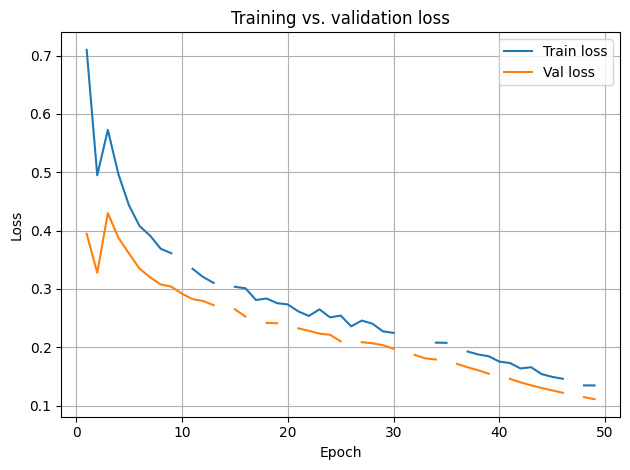

[InterveneGPT] Outcomes not in tokenizer vocab (ignored): ['DISGLYCEMIA_EVENT_Hyperglycemia', 'DISGLYCEMIA_EVENT_Hypoglycemia']
[InterveneGPT]: Total params: 6.40 M

  pretrain_transformer  |  2026-05-02 23:31:04
  model config      : {'time2vec_dim': 32, 'embed_dim': 256, 'n_head': 4, 'n_layer': 4, 'dropout': 0.1, 'bias': True, 'ctx_dim': 2}
  training settings : {'phase1_n_epochs': 50, 'phase2_n_epochs': 50, 'phase3_n_epochs': 50, 'lr_warmup_epochs': 5, 'early-stop-patience': 5, 'early-stop-min-delta-rel': 0.001, 'phase1_learning_rate': 0.0003, 'phase2_learning_rate': 0.0005, 'phase3_learning_rate': 0.0001, 'weight_decay': 0.001, 'batch_size': 16, 'grad_accumulation_steps': 4, 'phase1_bce_window_hours': 3.0, 'phase2_bce_window_hours': 12.0, 'phase1_scheduler': {'bce_only_epochs': 3, 'aux_fraction_caps': {'mlm': 0.2, 'dt': 0.2}, 'order': [['mlm', 'dt']], 'ramp_epochs': {'mlm': 0, 'dt': 0}}, 'phase2_scheduler': {'bce_only_epochs': 5, 'aux_fraction_caps': {'ce': 2.0, 'dt': 1.0, 'outcome

[Phase-2]: Epoch 00
        --> Train=0.0367 (BCE=0.0367, CE=0.0000, Out=0.0000, Δt=0.0000)
        --> Val=0.0286 (BCE=0.0286, CE=0.0000, Out=0.0000, Δt=0.0000)
[Scheduler] epoch=0 | ce:λ=0.0000(pending) | dt:λ=0.0000(pending) | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 01
        --> Train=0.0366 (BCE=0.0366, CE=0.0000, Out=0.0000, Δt=0.0000)
        --> Val=0.0285 (BCE=0.0285, CE=0.0000, Out=0.0000, Δt=0.0000)
[Scheduler] epoch=1 | ce:λ=0.0000(pending) | dt:λ=0.0000(pending) | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 02
        --> Train=0.0389 (BCE=0.0389, CE=0.0000, Out=0.0000, Δt=0.0000)
        --> Val=0.0283 (BCE=0.0283, CE=0.0000, Out=0.0000, Δt=0.0000)
[Scheduler] epoch=2 | ce:λ=0.0000(pending) | dt:λ=0.0000(pending) | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 03
        --> Train=0.0371 (BCE=0.0371, CE=0.0000, Out=0.0000, Δt=0.0000)
        --> Val=0.0282 (BCE=0.0282, CE=0.0000, Out=0.0000, Δt=0.0000)
[Scheduler] epoch=3 | ce:λ=0.0000(pending) | dt:λ=0.0000(pending) | outcome:λ=0.0000(pending)


...

[Phase-2]: Epoch 45
        --> Train=0.0506 (BCE=0.0197, CE=0.0301, Out=0.0000, Δt=0.0007)
        --> Val=0.0495 (BCE=0.0177, CE=0.0310, Out=0.0000, Δt=0.0008)
[Scheduler] epoch=45 | ce:λ=0.0245/λ_max=0.0245 | dt:λ=0.0458/λ_max=0.0458 | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 46
        --> Train=0.0501 (BCE=0.0192, CE=0.0300, Out=0.0000, Δt=0.0009)
        --> Val=0.0491 (BCE=0.0177, CE=0.0306, Out=0.0000, Δt=0.0008)
[Scheduler] epoch=46 | ce:λ=0.0245/λ_max=0.0245 | dt:λ=0.0458/λ_max=0.0458 | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 47
        --> Train=0.0491 (BCE=0.0195, CE=0.0287, Out=0.0000, Δt=0.0008)
        --> Val=0.0485 (BCE=0.0179, CE=0.0298, Out=0.0000, Δt=0.0008)
[Scheduler] epoch=47 | ce:λ=0.0245/λ_max=0.0245 | dt:λ=0.0458/λ_max=0.0458 | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 48
        --> Train=0.0487 (BCE=0.0200, CE=0.0280, Out=0.0000, Δt=0.0008)
        --> Val=0.0483 (BCE=0.0177, CE=0.0297, Out=0.0000, Δt=0.0009)
[Scheduler] epoch=48 | ce:λ=0.0245/λ_max=0.0245 | dt:λ=0.0458/λ_max=0.0458 | outcome:λ=0.0000(pending)


[Phase-2]: Epoch 49
        --> Train=0.0480 (BCE=0.0197, CE=0.0274, Out=0.0000, Δt=0.0008)
        --> Val=0.0482 (BCE=0.0178, CE=0.0295, Out=0.0000, Δt=0.0009)
[Scheduler] epoch=49 | ce:λ=0.0245/λ_max=0.0245 | dt:λ=0.0458/λ_max=0.0458 | outcome:λ=0.0000(pending)


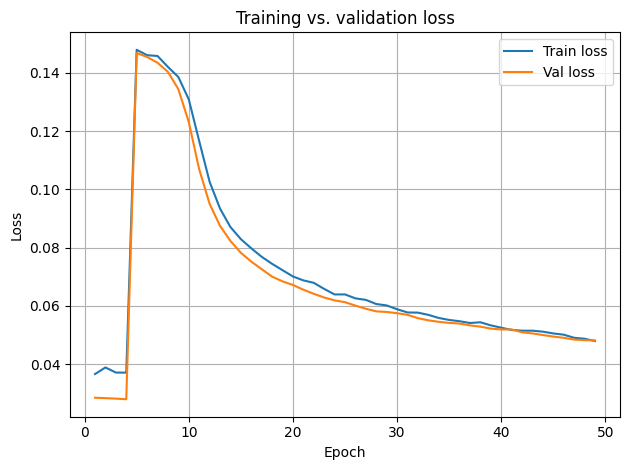


  finetune_transformer  |  2026-05-02 23:44:12
  model config      : {'time2vec_dim': 32, 'embed_dim': 256, 'n_head': 4, 'n_layer': 4, 'dropout': 0.1, 'bias': True, 'ctx_dim': 2}
  training settings : {'phase1_n_epochs': 50, 'phase2_n_epochs': 50, 'phase3_n_epochs': 50, 'lr_warmup_epochs': 5, 'early-stop-patience': 5, 'early-stop-min-delta-rel': 0.001, 'phase1_learning_rate': 0.0003, 'phase2_learning_rate': 0.0005, 'phase3_learning_rate': 0.0001, 'weight_decay': 0.001, 'batch_size': 16, 'grad_accumulation_steps': 4, 'phase1_bce_window_hours': 3.0, 'phase2_bce_window_hours': 12.0, 'phase1_scheduler': {'bce_only_epochs': 3, 'aux_fraction_caps': {'mlm': 0.2, 'dt': 0.2}, 'order': [['mlm', 'dt']], 'ramp_epochs': {'mlm': 0, 'dt': 0}}, 'phase2_scheduler': {'bce_only_epochs': 5, 'aux_fraction_caps': {'ce': 2.0, 'dt': 1.0, 'outcome': 0.2}, 'order': [['ce', 'dt'], ['outcome']], 'ramp_epochs': {'ce': 0, 'dt': 0, 'outcome': 3}, 'plateau_min_delta': 0.001, 'plateau_patience': [2]}, 'outcome_decay_

[Phase-3]: Epoch 00  train=17.7515 (outcome=9.5061, ce=8.2454)  val=15.8161 (outcome=7.5350, ce=8.2812)
[Phase-3]: Current best model saved.


[Phase-3]: Epoch 01  train=15.2961 (outcome=7.2352, ce=8.0609)  val=14.8938 (outcome=6.8161, ce=8.0776)
[Phase-3]: Current best model saved.


[Phase-3]: Epoch 02  train=14.9191 (outcome=7.0122, ce=7.9069)  val=14.7806 (outcome=6.8126, ce=7.9680)
[Phase-3]: Current best model saved.


[Phase-3]: Epoch 03  train=14.8364 (outcome=7.0375, ce=7.7989)  val=14.6461 (outcome=6.8048, ce=7.8413)
[Phase-3]: Current best model saved.


...

[Phase-3]: Epoch 45  train=10.6562 (outcome=6.7066, ce=3.9496)  val=10.8840 (outcome=6.7636, ce=4.1204)
[Phase-3]: Current best model saved.


[Phase-3]: Epoch 46  train=10.8569 (outcome=6.9875, ce=3.8695)  val=10.7273 (outcome=6.7638, ce=3.9635)
[Phase-3]: Current best model saved.


[Phase-3]: Epoch 47  train=10.9073 (outcome=6.8349, ce=4.0723)  val=10.7347 (outcome=6.7543, ce=3.9804)


[Phase-3]: Epoch 48  train=11.2610 (outcome=7.2684, ce=3.9926)  val=10.7631 (outcome=6.7580, ce=4.0051)


[Phase-3]: Epoch 49  train=10.6586 (outcome=6.9754, ce=3.6833)  val=10.7371 (outcome=6.7601, ce=3.9770)


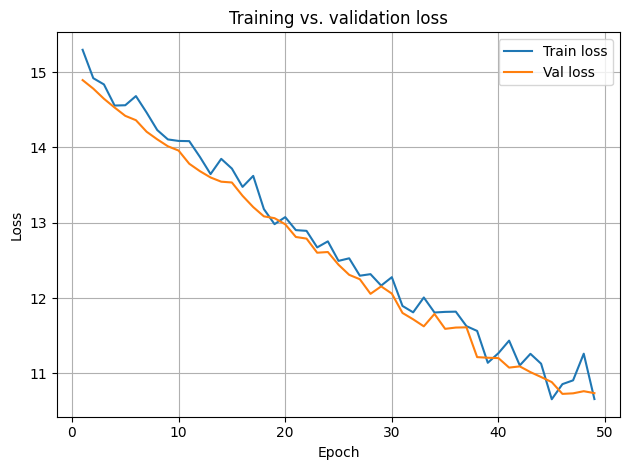

Model ready for evaluation.


In [30]:
def _load_embedder_checkpoint(best_path, tokenizer):
    """Load best Phase-1 checkpoint, falling back to last if best is not yet saved."""
    ckpt_best = Path(best_path).resolve()
    ckpt_last = ckpt_best.parent / "ckpt_last.pt"
    ckpt = ckpt_best if ckpt_best.exists() else ckpt_last
    if not ckpt.exists():
        raise FileNotFoundError(
            "No Phase-1 checkpoint found. Run with RUN_PHASE1=True first."
        )
    print(f"Loading embedder from: {ckpt}")
    model, *_ = embedder.EMREmbedding.load(ckpt, tokenizer=tokenizer)
    return model

def _load_transformer_checkpoint(best_path, embedder_model):
    """Load best Phase-2 checkpoint, falling back to last if best is not yet saved."""
    ckpt_best = Path(best_path).resolve()
    ckpt_last = ckpt_best.parent / "ckpt_last.pt"
    ckpt = ckpt_best if ckpt_best.exists() else ckpt_last
    if not ckpt.exists():
        raise FileNotFoundError(
            "No Phase-2 checkpoint found. Run with RUN_PHASE2=True first."
        )
    print(f"Loading transformer from: {ckpt}")
    model, *_ = transformer.InterveneGPT.load(ckpt, embedder=embedder_model)
    return model


# Phase 1: embedder
# RUN_PHASE1=True : always start with a fresh embedder instance.
#   train_embedder() handles checkpoint loading internally when RESUME_TRAINING=True,
#   restoring weights, optimizer, scheduler, and aux-scheduler state.
# RUN_PHASE1=False: load the best available Phase-1 checkpoint directly.

if RUN_PHASE1:
    embedder_model = embedder.EMREmbedding(
        tokenizer=tokenizer,
        ctx_dim=model_config.MODEL_CONFIG.get("ctx_dim"),
        time2vec_dim=model_config.MODEL_CONFIG.get("time2vec_dim"),
        embed_dim=model_config.MODEL_CONFIG.get("embed_dim"),
    )
    embedder_model, _, _ = embedder.train_embedder(
        embedder=embedder_model,
        train_loader=train_dl,
        val_loader=val_dl,
        resume=RESUME_TRAINING,
        checkpoint_path=model_config.PHASE1_CHECKPOINT,
        training_settings=model_config.TRAINING_SETTINGS,
    )
else:
    embedder_model = _load_embedder_checkpoint(model_config.PHASE1_CHECKPOINT, tokenizer)


# Phase 2: transformer
# RUN_PHASE2=True : always initialize a fresh InterveneGPT instance wrapping the embedder above.
#   pretrain_transformer() handles checkpoint loading internally when RESUME_TRAINING=True.
#   The fresh InterveneGPT passed in is discarded on resume -- only its architecture is used.
# RUN_PHASE2=False: load the best available Phase-2 checkpoint directly.

if RUN_PHASE2:
    model = transformer.InterveneGPT(cfg=model_config.MODEL_CONFIG, embedder=embedder_model)
    model, _, _ = transformer.pretrain_transformer(
        model=model,
        train_dl=oversampled_train_dl,
        val_dl=val_dl,
        resume=RESUME_TRAINING,
        checkpoint_path=model_config.PHASE2_CHECKPOINT,
        training_settings=model_config.TRAINING_SETTINGS,
    )
else:
    model = _load_transformer_checkpoint(model_config.PHASE2_CHECKPOINT, embedder_model)


# Phase 3: outcome head fine-tuning
# Uses natural-distribution batches (oversample=False) so pos_weight in
# BCEWithLogitsLoss correctly compensates for class imbalance without
# double-counting (unlike Phase-2 which uses oversample=True).
# RUN_PHASE3=False: loads Phase-3 checkpoint if available (full InterveneGPT.load()),
#   otherwise the Phase-2 outcome head is used as-is.

if RUN_PHASE3:
    model, _, _ = transformer.finetune_transformer(
        model=model,
        train_dl=train_dl,
        val_dl=val_dl,
        resume=RESUME_TRAINING,
        checkpoint_path=model_config.PHASE3_CHECKPOINT,
        training_settings=model_config.TRAINING_SETTINGS,
    )
else:
    p3_ckpt = Path(model_config.PHASE3_CHECKPOINT)
    p3_last = p3_ckpt.parent / "ckpt_last.pt"
    p3_path = p3_last if p3_last.exists() else (p3_ckpt if p3_ckpt.exists() else None)
    if p3_path:
        print(f"Loading Phase-3 checkpoint from: {p3_path}")
        model, *_ = transformer.InterveneGPT.load(p3_path, embedder=embedder_model)
    else:
        print("No Phase-3 checkpoint found; using outcome head from Phase-2.")

model.eval()
print("Model ready for evaluation.")

## 3) Risk-Based Complication Prediction

Generates a single trajectory per patient (K=1, autoregressive) and reads the outcome head at every step.
This produces a **risk curve** per complication over predicted time.

Evaluation uses **time-stratified AUC**: at each 24 h window the max predicted probability within that
window is compared against whether the complication occurs within that **same 24 h window** in the ground truth.
AUROC and AUPRC are computed per complication then averaged across time windows.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm.auto import tqdm
from pathlib import Path

from intervene_ar.inference import generate
from intervene_ar.config import dataset_config

# Load best model (safe to re-run independently after a kernel restart)
# Prefers Phase-3 best -> Phase-3 last -> Phase-2 best -> Phase-2 last.
# Requires `tokenizer` to be in scope (run the data cell first).

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _pick_ckpt(*candidates):
    """Return the first existing path among candidates, or None."""
    for p in candidates:
        if Path(p).exists():
            return Path(p)
    return None

_emb_ckpt = _pick_ckpt(model_config.PHASE1_CHECKPOINT,
                        Path(model_config.PHASE1_CHECKPOINT).parent / "ckpt_last.pt")
if _emb_ckpt is None:
    raise FileNotFoundError("No Phase-1 checkpoint found -- run Phase-1 training first.")

_p3_best = Path(model_config.PHASE3_CHECKPOINT)
_p3_last = _p3_best.parent / "ckpt_last.pt"
_p2_best = Path(model_config.PHASE2_CHECKPOINT)
_p2_last = _p2_best.parent / "ckpt_last.pt"
_tfm_ckpt = _pick_ckpt(_p3_best, _p3_last, _p2_best, _p2_last)
if _tfm_ckpt is None:
    raise FileNotFoundError("No Phase-2 or Phase-3 checkpoint found -- run training first.")

print(f"Loading embedder  : {_emb_ckpt}")
_embedder_model, *_ = embedder.EMREmbedding.load(_emb_ckpt, tokenizer=tokenizer,
                                                  map_location=DEVICE)

print(f"Loading transformer: {_tfm_ckpt}")
model, *_ = transformer.InterveneGPT.load(_tfm_ckpt, embedder=_embedder_model,
                                  map_location=DEVICE)
model = model.cuda()
model.eval()
print(f"Model ready on {DEVICE}.")

OUTCOME_NAMES = model.outcome_names   # list of outcome token strings
P_COLS        = [f'P_{n}' for n in OUTCOME_NAMES]

Loading embedder  : C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase1\ckpt_best.pt
Loading transformer: C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase3\ckpt_best.pt
[InterveneGPT] Outcomes not in tokenizer vocab (ignored): ['DISGLYCEMIA_EVENT_Hyperglycemia', 'DISGLYCEMIA_EVENT_Hypoglycemia']
[InterveneGPT]: Total params: 6.40 M
Model ready on cpu.


### 3a) Trained Model Debugging Block

In [ ]:
from intervene_ar.diagnose import (
    probe_legality_starvation,
    probe_terminal_logits,
    probe_dt_head,
    probe_dt_components,
    probe_outcome_label_alignment,
    probe_calibration_by_abs_time,
    probe_outcome_logit_distribution,
    probe_outcome_lm_coupling,
)

probe_legality_starvation(model, val_dl, tokenizer)            # confirms terminals aren't masked at GT positions
probe_terminal_logits(model, val_dl, tokenizer, n_batches=2)   # explains "no natural stop"
probe_dt_head(model, val_dl, n_batches=2)                       # detects Δt collapse
probe_dt_components(model, val_dl, n_batches=2)                  # inspects Δt components
probe_outcome_label_alignment(model, val_dl, tokenizer, n_batches=2)  # finds RELEASE flip
probe_calibration_by_abs_time(model, val_dl, tokenizer, n_batches=2)  # Time2Vec OOD
probe_outcome_logit_distribution(model, val_dl, n_batches=2)   # confirms over-sharp logits
probe_outcome_lm_coupling(model, val_dl, n_batches=2)  # inspects LM coupling

### 3b) Ground Truth Extraction

In [ ]:
# ---------------------------------------------------------------------------
# Evaluation constants (locked, matching the headline metrics)
# ---------------------------------------------------------------------------
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from intervene_ar.config.dataset_config import OUTCOME_RARE_THRESHOLD_PCT

EVAL_INPUT_DAYS         = 2      # days of patient history used as generation seed
EVAL_WINDOW_HOURS       = 24.0   # non-overlapping prediction window size
EVAL_GRACE_HOURS        = 24.0   # tolerance added to each window edge for positive labelling
EVAL_MAX_LEN            = 500    # max generated steps per patient
EVAL_TEMPERATURE        = 1.0    # sampling temperature
EVAL_FULL_HORIZON_HOURS = 336.0  # cap per-patient eval horizon at 14 days

# Prevalence floor for an outcome's AUC to be emitted (same 1% used at data-load time).
EVAL_PREVALENCE_THRESHOLD = OUTCOME_RARE_THRESHOLD_PCT / 100.0

# RELEASE_EVENT is the negation of DEATH in this cohort; including both in the
# AUC headline double-counts the same terminal-event ranking task. RELEASE stays
# in the LM vocab (model emits it -> trajectory-length signal) and is reported
# via length-of-stay MAE instead.
AUC_EXCLUDE = ("RELEASE_EVENT",)


def _min_positives(n_patients, threshold=EVAL_PREVALENCE_THRESHOLD):
    return max(1, int(round(threshold * n_patients)))


# ---------------------------------------------------------------------------
# Ground-truth extraction
# ---------------------------------------------------------------------------
def extract_ground_truth(eval_ds, outcome_names):
    """{pid: {outcome: first_time_hours or np.inf}} from full (untruncated) sequences."""
    outcome_set = set(outcome_names)
    tok_col = "PositionToken" if "PositionToken" in next(iter(eval_ds.patient_groups.values())).columns else "Token"
    gt = {}
    for pid in eval_ds.patient_ids:
        df = eval_ds.patient_groups[pid]
        patient_gt = {n: np.inf for n in outcome_names}
        for _, row in df.iterrows():
            tok = row[tok_col]
            if tok in outcome_set:
                t = row["TimePoint"]
                if t < patient_gt[tok]:
                    patient_gt[tok] = t
        gt[pid] = patient_gt
    return gt


def extract_ground_truth_episodes(eval_ds, outcome_names):
    """{pid: {outcome: [t1, t2, ...]}} all occurrence times."""
    outcome_set = set(outcome_names)
    tok_col = "PositionToken" if "PositionToken" in next(iter(eval_ds.patient_groups.values())).columns else "Token"
    gt = {}
    for pid in eval_ds.patient_ids:
        df = eval_ds.patient_groups[pid]
        patient_gt = {n: [] for n in outcome_names}
        for _, row in df.iterrows():
            tok = row[tok_col]
            if tok in outcome_set:
                patient_gt[tok].append(row["TimePoint"])
        gt[pid] = patient_gt
    return gt


def extract_patient_horizons(eval_ds, full_horizon_hours=EVAL_FULL_HORIZON_HOURS):
    """Per-patient evaluation horizon = min(last GT event time, full_horizon_hours)."""
    out = {}
    for pid in eval_ds.patient_ids:
        df = eval_ds.patient_groups[pid]
        last_t = float(df["TimePoint"].max()) if len(df) else 0.0
        out[pid] = min(last_t, full_horizon_hours)
    return out


gt_first         = extract_ground_truth(eval_ds, OUTCOME_NAMES)
gt_episodes      = extract_ground_truth_episodes(eval_ds, OUTCOME_NAMES)
patient_horizons = extract_patient_horizons(eval_ds)

print(f"Ground truth extracted for {len(gt_first)} patients.")
horiz = np.array(list(patient_horizons.values()), dtype=float)
print(f"Horizons (h): median={np.median(horiz):.1f}, mean={horiz.mean():.1f}, "
      f"p90={np.percentile(horiz, 90):.1f}, max={horiz.max():.1f}")

# Aliases used by the calibration cell below.
gt_labels          = gt_first
gt_labels_episodes = gt_episodes

summary = {n: sum(1 for p in gt_first if gt_first[p][n] < np.inf) for n in OUTCOME_NAMES}
pd.Series(summary, name="patients_with_complication").sort_values(ascending=False)


### 3c) Generate Risk Curves

In [ ]:
# Truncated eval dataset (EVAL_INPUT_DAYS-day seed) + autoregressive generation.
print(f"Building truncated eval dataset ({EVAL_INPUT_DAYS}-day input window)...")
eval_input_processor = dataset.DataProcessor(
    eval_temporal_raw.copy(), eval_ctx_raw.copy(),
    scaler=scaler,
    tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
    max_input_days=EVAL_INPUT_DAYS,
)
eval_input_temporal_df, eval_input_ctx_df = eval_input_processor.run()
eval_ds_input = dataset.EMRDataset(eval_input_temporal_df, eval_input_ctx_df, tokenizer=tokenizer)

risk_df = generate(
    model, eval_ds_input,
    max_len=EVAL_MAX_LEN,
    temperature=EVAL_TEMPERATURE,
    top_k=None,
    rep_decay=0.6,
    collect_risk_scores=True,
)
print(f'Risk curves: {len(risk_df)} rows, {risk_df["PatientId"].nunique()} patients.')
risk_df.head()


### 3d) Headline Metrics — patient-level peak-detector AUC


In [ ]:
# === HEADLINE: patient-level peak-detector AUC + F1 ============================
# For each (patient, outcome): score = max P_outcome(t) over all generated positions,
# label = 1 iff the outcome occurred at any point in the GT trajectory.
# AUROC/AUPRC pooled once per outcome -> stable on rare outcomes.
# RELEASE_EVENT excluded (negation of DEATH in this cohort).
def per_patient_max_auc(risk_df, gt_episodes, outcome_names, min_positives=None):
    gen_df   = risk_df[risk_df["IsInput"] == 0]
    p_cols   = [f"P_{n}" for n in outcome_names]
    all_pids = list(risk_df["PatientId"].unique())
    n_patients = len(all_pids)
    if min_positives is None:
        min_positives = _min_positives(n_patients)

    max_per_patient = {pid: {c: 0.0 for c in p_cols} for pid in all_pids}
    if len(gen_df):
        grouped = gen_df.groupby("PatientId")[p_cols].max()
        for pid, row in grouped.iterrows():
            for c in p_cols:
                max_per_patient[pid][c] = float(row[c])

    rows = []
    for name in outcome_names:
        pcol = f"P_{name}"
        scores, labels = [], []
        for pid in all_pids:
            scores.append(max_per_patient[pid][pcol])
            labels.append(int(len(gt_episodes.get(pid, {}).get(name, [])) > 0))
        labels = np.array(labels); scores = np.array(scores)
        n_pos = int(labels.sum()); n_neg = int((1 - labels).sum())
        prevalence = n_pos / max(1, n_pos + n_neg)

        if n_pos < min_positives or n_neg < min_positives:
            rows.append({"outcome": name, "auroc": np.nan, "auprc": np.nan,
                         "max_f1": np.nan, "max_f1_threshold": np.nan, "f1_at_0_5": np.nan,
                         "n_pos": n_pos, "n_neg": n_neg, "prevalence": prevalence})
            continue

        precisions, recalls, thresholds = precision_recall_curve(labels, scores)
        f1s = np.where((precisions + recalls) > 0,
                       2 * precisions * recalls / np.maximum(precisions + recalls, 1e-12), 0.0)
        best_idx = int(np.argmax(f1s))
        max_f1 = float(f1s[best_idx])
        max_f1_thr = float(thresholds[best_idx]) if best_idx < len(thresholds) else (
            float(thresholds[-1]) if len(thresholds) else 0.5)

        preds_05 = (scores >= 0.5).astype(int)
        tp = int(((preds_05 == 1) & (labels == 1)).sum())
        fp = int(((preds_05 == 1) & (labels == 0)).sum())
        fn = int(((preds_05 == 0) & (labels == 1)).sum())
        prec_05 = tp / max(tp + fp, 1); rec_05 = tp / max(tp + fn, 1)
        f1_at_0_5 = 2 * prec_05 * rec_05 / (prec_05 + rec_05) if (prec_05 + rec_05) > 0 else 0.0

        rows.append({
            "outcome": name,
            "auroc": float(roc_auc_score(labels, scores)),
            "auprc": float(average_precision_score(labels, scores)),
            "max_f1": max_f1, "max_f1_threshold": max_f1_thr, "f1_at_0_5": float(f1_at_0_5),
            "n_pos": n_pos, "n_neg": n_neg, "prevalence": prevalence,
        })
    return pd.DataFrame(rows).set_index("outcome").sort_values("auroc", ascending=False)


def weighted_mean_auc(auc_table, by="n_pos"):
    """Support-weighted mean of AUROC / AUPRC / F1 across outcomes with non-NaN AUC."""
    tbl = auc_table.dropna(subset=["auroc"])
    if len(tbl) == 0:
        nan = float("nan")
        return {"auroc_weighted": nan, "auprc_weighted": nan,
                "auroc_simple": nan, "auprc_simple": nan,
                "max_f1_weighted": nan, "max_f1_simple": nan,
                "f1_at_0_5_weighted": nan, "f1_at_0_5_simple": nan,
                "n_outcomes_used": 0}
    w = tbl[by].astype(float).values
    w = w / w.sum() if w.sum() > 0 else np.ones_like(w) / len(w)
    return {
        "auroc_weighted":     float((tbl["auroc"].values * w).sum()),
        "auprc_weighted":     float((tbl["auprc"].values * w).sum()),
        "auroc_simple":       float(tbl["auroc"].mean()),
        "auprc_simple":       float(tbl["auprc"].mean()),
        "max_f1_weighted":    float((tbl["max_f1"].values    * w).sum()),
        "max_f1_simple":      float(tbl["max_f1"].mean()),
        "f1_at_0_5_weighted": float((tbl["f1_at_0_5"].values * w).sum()),
        "f1_at_0_5_simple":   float(tbl["f1_at_0_5"].mean()),
        "n_outcomes_used":    int(len(tbl)),
    }


auc_outcome_names = [n for n in OUTCOME_NAMES if n not in AUC_EXCLUDE]
print(f"AUC computed over {len(auc_outcome_names)} outcomes (excluded from headline: {list(AUC_EXCLUDE)}).")

patient_auc_table = per_patient_max_auc(risk_df, gt_episodes, auc_outcome_names)
patient_mean      = weighted_mean_auc(patient_auc_table, by="n_pos")

print(f"\n[Patient AUC headline]")
print(f"  auroc_weighted  = {patient_mean['auroc_weighted']:.4f}")
print(f"  auprc_weighted  = {patient_mean['auprc_weighted']:.4f}")
print(f"  max_f1_weighted = {patient_mean['max_f1_weighted']:.4f}")
print(f"  f1@0.5_weighted = {patient_mean['f1_at_0_5_weighted']:.4f}")
print(f"  n_outcomes_used = {patient_mean['n_outcomes_used']}")
patient_auc_table.round(4)


### 3e) Peak-time MAE (nearest GT), Length-of-Stay, generation stats


In [ ]:
# Peak-time MAE to the NEAREST ground-truth occurrence (fair when complications recur).
def time_accuracy_nearest(risk_df, gt_episodes, outcome_names):
    gen_df = risk_df[risk_df["IsInput"] == 0].copy()
    if len(gen_df) == 0:
        return pd.DataFrame()
    p_cols = [f"P_{n}" for n in outcome_names]
    idxmax = gen_df.groupby("PatientId")[p_cols].idxmax()
    rows = []
    for name in outcome_names:
        pcol = f"P_{name}"
        pred_t = gen_df.loc[idxmax[pcol].dropna().astype(int), ["PatientId", "TimePoint"]]
        pred_t = pred_t.set_index("PatientId")["TimePoint"]
        errors = []
        for pid, pt in pred_t.items():
            episodes = gt_episodes.get(pid, {}).get(name, [])
            if not episodes:
                continue
            errors.append(min(abs(pt - t_gt) for t_gt in episodes))
        rows.append({"outcome": name,
                     "mae_hours": float(np.mean(errors)) if errors else np.nan,
                     "n_patients": len(errors)})
    return pd.DataFrame(rows).set_index("outcome").sort_values("mae_hours")


# Length-of-stay regression — replaces RELEASE peak-MAE with a trajectory-length
# regression (admission -> end of input+generated trajectory vs GT release time).
def length_of_stay_mae(risk_df, gt_episodes, release_token="RELEASE_EVENT"):
    errors, gt_vals, pred_vals = [], [], []
    for pid, sub in risk_df.groupby("PatientId"):
        gt_releases = gt_episodes.get(pid, {}).get(release_token, [])
        if not gt_releases:
            continue
        gt_los   = float(min(gt_releases))
        pred_los = float(sub["TimePoint"].max())
        errors.append(abs(pred_los - gt_los))
        gt_vals.append(gt_los); pred_vals.append(pred_los)
    if not errors:
        return {"mae_hours": float("nan"), "median_hours": float("nan"),
                "p90_hours": float("nan"), "n_patients": 0,
                "gt_mean_hours": float("nan"), "pred_mean_hours": float("nan")}
    errs = np.asarray(errors)
    return {"mae_hours": float(errs.mean()),
            "median_hours": float(np.median(errs)),
            "p90_hours": float(np.percentile(errs, 90)),
            "n_patients": int(len(errs)),
            "gt_mean_hours": float(np.mean(gt_vals)),
            "pred_mean_hours": float(np.mean(pred_vals))}


# Trajectory-collapse failure-mode diagnostics — span vs GT horizon ratio.
def compute_gen_stats(risk_df, patient_horizons=None):
    stats = {"gen_n_patients": int(risk_df["PatientId"].nunique())}
    gen_df = risk_df[risk_df["IsInput"] == 0]
    if len(gen_df) == 0:
        return stats
    per_pat_steps = gen_df.groupby("PatientId").size()
    span     = gen_df.groupby("PatientId")["TimePoint"].max() - gen_df.groupby("PatientId")["TimePoint"].min()
    seed_end = gen_df.groupby("PatientId")["TimePoint"].min()

    term_df = gen_df[gen_df["IsTerminal"] == 1]
    if len(term_df):
        term = term_df.groupby("PatientId")["TimePoint"].min()
        within24 = (term - seed_end.loc[term.index]).lt(24.0)
        n_terminal = int(len(term)); frac_early = float(within24.mean())
    else:
        n_terminal = 0; frac_early = 0.0

    stats.update({
        "gen_median_steps": float(per_pat_steps.median()),
        "gen_p90_steps":    float(per_pat_steps.quantile(0.9)),
        "gen_median_hours": float(span.median()),
        "gen_mean_hours":   float(span.mean()),
        "gen_p90_hours":    float(span.quantile(0.9)),
        "gen_max_hours":    float(span.max()),
        "gen_n_with_terminal":        n_terminal,
        "gen_frac_terminal_first24h": frac_early,
    })

    if patient_horizons:
        diffs, gt_spans = [], []
        for pid, s in span.items():
            if pid not in patient_horizons:
                continue
            gt_span = max(0.0, patient_horizons[pid] - seed_end.loc[pid])
            gt_spans.append(gt_span); diffs.append(abs(float(s) - gt_span))
        if diffs:
            stats["gen_length_mae_hrs"] = float(np.mean(diffs))
        if gt_spans:
            gt_arr = np.asarray(gt_spans, dtype=float)
            stats["gt_median_hours"] = float(np.median(gt_arr))
            stats["gt_mean_hours"]   = float(gt_arr.mean())
            stats["gen_to_gt_ratio_median"] = (float(span.median()) / stats["gt_median_hours"]) if stats["gt_median_hours"] > 0 else 0.0
            stats["gen_to_gt_ratio_mean"]   = (float(span.mean())   / stats["gt_mean_hours"])   if stats["gt_mean_hours"]   > 0 else 0.0
    return stats


peak_mae_table = time_accuracy_nearest(risk_df, gt_episodes, auc_outcome_names)
print("Peak-time MAE per outcome (hours):")
display(peak_mae_table.round(2))

los_stats = length_of_stay_mae(risk_df, gt_episodes)
print(f"\nLength-of-stay MAE: {los_stats['mae_hours']:.1f}h  "
      f"(median {los_stats['median_hours']:.1f}h, p90 {los_stats['p90_hours']:.1f}h, n={los_stats['n_patients']})")
print(f"  GT mean = {los_stats['gt_mean_hours']:.1f}h, pred mean = {los_stats['pred_mean_hours']:.1f}h")

gen_stats = compute_gen_stats(risk_df, patient_horizons=patient_horizons)
print("\nGeneration stats:")
for k, v in gen_stats.items():
    print(f"  {k:<30s} = {v}")


### 3e) Temperature Scaling Calibration

Learns one temperature scalar `T` per outcome by minimising NLL on the test set.
Using `logits / T` before sigmoid shrinks (T > 1) or sharpens (T < 1) probabilities
without changing rank order  so AUROC is unaffected, but calibration curves improve.

**When you need this**: when you want to interpret probability values (e.g. 'this patient
has a 70% chance of hyperglycemia') rather than just rank patients by risk.

In [19]:
def calibrate_temperature(model, dataset, gt_labels, outcome_names,
                           n_iter=200, lr=0.05):
    """
    Teacher-forced forward pass on the full (untruncated) test sequences.
    For each patient, takes the outcome-head logit at the *last real token*
    as the pre-calibration score, then learns T per outcome via LBFGS.

    Returns
    -------
    temperatures : dict  outcome_name -> float T
    cal_data     : dict  outcome_name -> (logits_np, labels_np)
    """
    device = next(model.parameters()).device
    tok    = model.embedder.tokenizer

    all_logits = {n: [] for n in outcome_names}
    all_labels = {n: [] for n in outcome_names}

    model.eval()
    with torch.no_grad():
        for pid in tqdm(dataset.patient_ids, desc='Collecting logits'):
            df      = dataset.patient_groups[pid]
            ctx_vec = torch.tensor(dataset.context_df.loc[pid].values,
                                   dtype=torch.float32).unsqueeze(0).to(device)
            pos_ids        = torch.tensor([df['PositionID'].tolist()], dtype=torch.long, device=device)
            parent_raw_ids = tok.tokenid2parent_raw_ids[pos_ids[0]].unsqueeze(0).to(device)
            concept_ids    = torch.tensor([df['ConceptID'].tolist()],  dtype=torch.long, device=device)
            value_ids      = torch.tensor([df['ValueID'].tolist()],    dtype=torch.long, device=device)
            abs_ts         = torch.tensor([df['TimePoint'].tolist()],  dtype=torch.float32, device=device) / 336.0

            _, _, outcome_logits, _, _ = model(
                parent_raw_ids=parent_raw_ids, concept_ids=concept_ids,
                value_ids=value_ids, position_ids=pos_ids,
                abs_ts=abs_ts, context_vec=ctx_vec
            )
            last_logit = outcome_logits[0, -1, :].cpu()  # [num_outcomes]

            for i, name in enumerate(outcome_names):
                gt_t  = gt_labels.get(pid, {}).get(name, np.inf)
                label = int(gt_t < np.inf)  # ever occurred?
                all_logits[name].append(last_logit[i].item())
                all_labels[name].append(label)

    temperatures = {}
    cal_data     = {}
    for name in outcome_names:
        logits_t = torch.tensor(all_logits[name], dtype=torch.float32)
        labels_t = torch.tensor(all_labels[name], dtype=torch.float32)
        if labels_t.sum() < 2:
            temperatures[name] = 1.0
            cal_data[name] = (logits_t.numpy(), labels_t.numpy())
            continue
        T = nn.Parameter(torch.ones(1))
        opt = torch.optim.LBFGS([T], lr=lr, max_iter=n_iter)
        def closure():
            opt.zero_grad()
            loss = nn.functional.binary_cross_entropy_with_logits(logits_t / T, labels_t)
            loss.backward()
            return loss
        opt.step(closure)
        temperatures[name] = T.item()
        cal_data[name] = (logits_t.detach().numpy(), labels_t.numpy())

    return temperatures, cal_data


# calibrate on the FULL test sequences (eval_ds)
temperatures, cal_data = calibrate_temperature(model, eval_ds, gt_labels, OUTCOME_NAMES)
pd.Series(temperatures, name='temperature_T').sort_values()


RELEASE_EVENT                        0.756657
CARDIO-VASCULAR_DISORDER_EVENT       1.622744
KETOACIDOSIS_EVENT                   1.661432
ACIDOSIS_EVENT                       1.921644
DIABETIC_COMA_EVENT                  1.996614
NEUROVASCULAR_COMPLICATION_EVENT     2.278542
SKIN_ULCER_EVENT                     2.301634
RETINOPATHY_EVENT                    2.385269
INFECTION_EVENT                      2.555942
KIDNEY_COMPLICATION_EVENT            2.620162
OTHER_COMPLICATION_EVENT             2.640872
NERVOUS_SYSTEM_DISORDER_EVENT        2.806769
HYPEROSMOLALITY_EVENT                2.958404
ACUTE_RESPIRATORY_DISORDER_EVENT     3.404931
ATHEROSCLEROSIS_EVENT                3.491274
DEATH_EVENT                         85.474007
Name: temperature_T, dtype: float64

### 3f) Reliability Diagram (before / after calibration)

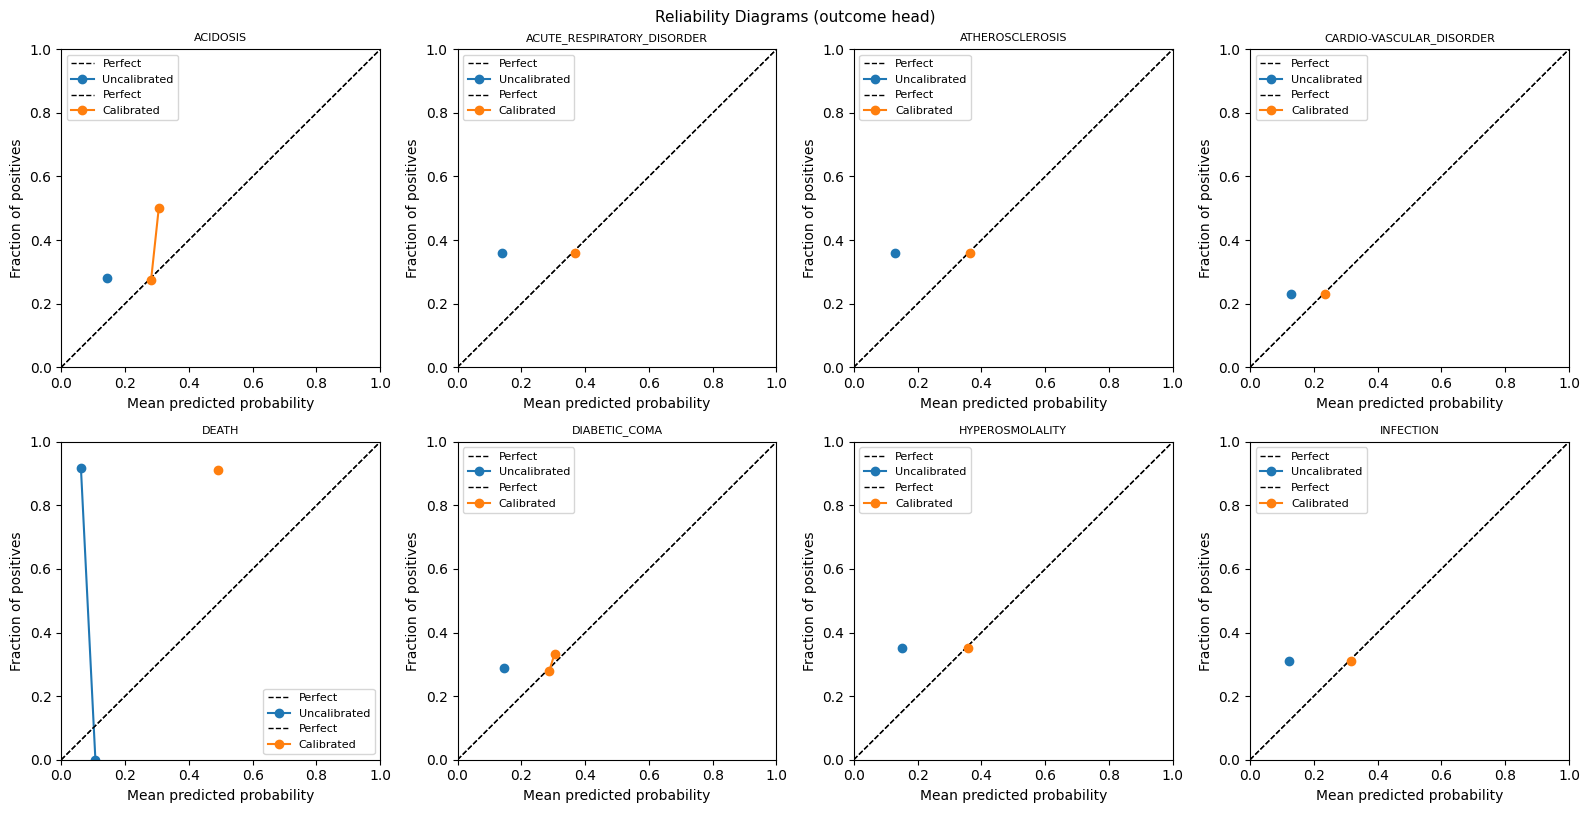

In [20]:
def reliability_diagram(ax, logits, labels, T=1.0, n_bins=10, label=''):
    probs = torch.sigmoid(torch.tensor(logits) / T).numpy()
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers, mean_true = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() > 0:
            bin_centers.append(probs[mask].mean())
            mean_true.append(labels[mask].mean())
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')
    ax.plot(bin_centers, mean_true, 'o-', label=label)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

# Plot outcomes that have enough positives
eligible = [n for n in OUTCOME_NAMES if cal_data[n][1].sum() >= 5]
n_plots  = min(len(eligible), 8)
fig, axes = plt.subplots(2, (n_plots + 1) // 2, figsize=(4 * ((n_plots + 1) // 2), 8))
axes = axes.flatten()
for ax, name in zip(axes, eligible[:n_plots]):
    logits_np, labels_np = cal_data[name]
    ax.set_title(name.replace('_EVENT', '').replace('_COMPLICATION', ''), fontsize=8)
    reliability_diagram(ax, logits_np, labels_np, T=1.0,            label='Uncalibrated')
    reliability_diagram(ax, logits_np, labels_np, T=temperatures[name], label='Calibrated')
for ax in axes[n_plots:]:
    ax.set_visible(False)
plt.tight_layout()
plt.suptitle('Reliability Diagrams (outcome head)', y=1.01, fontsize=11)
plt.show()

### 3g) Sample Patient Risk Curve

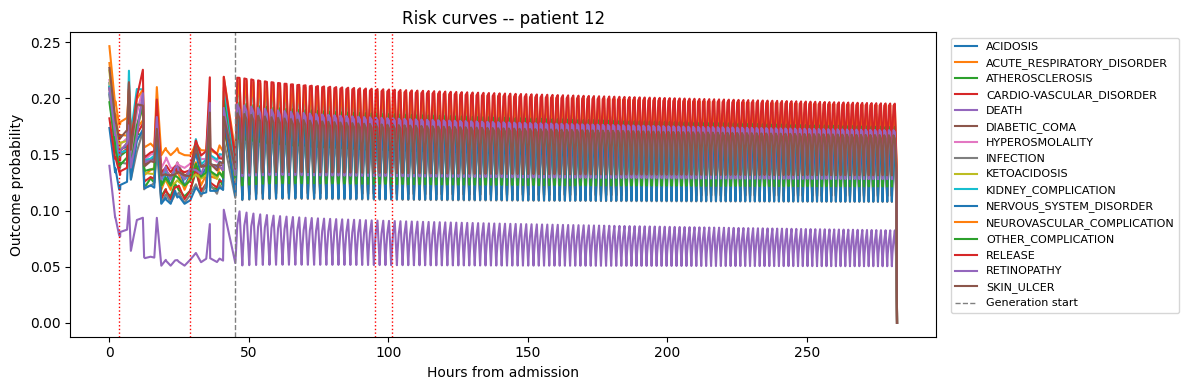

In [21]:
# Visualise the risk trajectory for one patient over time.
# Change `sample_pid` to inspect a specific patient.
sample_pid = risk_df['PatientId'].iloc[0]
patient_risk = risk_df[risk_df['PatientId'] == sample_pid].copy()

# Outcomes that actually have some signal for this patient
gen_risk = patient_risk[patient_risk['IsInput'] == 0]
active = [n for n in OUTCOME_NAMES if gen_risk[f'P_{n}'].max() > 0.05]
if not active:
    active = OUTCOME_NAMES[:4]  # fallback: show first four

fig, ax = plt.subplots(figsize=(12, 4))
for name in active:
    ax.plot(patient_risk['TimePoint'], patient_risk[f'P_{name}'], label=name.replace('_EVENT',''), lw=1.5)

# Mark where input ends
input_end = patient_risk[patient_risk['IsInput'] == 1]['TimePoint'].max()
ax.axvline(input_end, color='gray', linestyle='--', lw=1, label='Generation start')

# Mark actual ground truth occurrences (if patient in gt_labels)
if sample_pid in gt_labels:
    for name, t in gt_labels[sample_pid].items():
        if t < np.inf and name in active:
            ax.axvline(t, color='red', linestyle=':', lw=1)

ax.set_xlabel('Hours from admission')
ax.set_ylabel('Outcome probability')
ax.set_title(f'Risk curves -- patient {sample_pid}')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()